In [13]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("../Data/olist_orders_dataset.csv")
reviews = pd.read_csv("../Data/olist_order_reviews_dataset.csv")

In [14]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [15]:
orders = orders[
    orders["order_purchase_timestamp"] < "2018-09-01"
].copy()

In [16]:
orders.shape[0]

99421

In [17]:
orders["DeliveryStatus"] = "Unknown"

orders.loc[
    orders["order_delivered_customer_date"].dt.date
    <= orders["order_estimated_delivery_date"].dt.date,
    "DeliveryStatus"
] = "On-Time"

orders.loc[
    orders["order_delivered_customer_date"].dt.date
    > orders["order_estimated_delivery_date"].dt.date,
    "DeliveryStatus"
] = "Late"

In [18]:
delivery_counts = orders["DeliveryStatus"].value_counts()

on_time_rate = (
    delivery_counts["On-Time"]
    /
    (delivery_counts["On-Time"] + delivery_counts["Late"])
    * 100
)

round(on_time_rate, 2)

np.float64(93.23)

In [19]:
orders["DelayDays"] = (
    orders["order_delivered_customer_date"].dt.normalize()
    - orders["order_estimated_delivery_date"].dt.normalize()
).dt.days

In [20]:
late_orders = orders[
    orders["DeliveryStatus"] == "Late"
].copy()

late_orders["DelayDays"].mean()

np.float64(10.6203519510329)

In [21]:
orders_reviews = orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

In [22]:
review_by_delivery = (
    orders_reviews[
        orders_reviews["DeliveryStatus"].isin(["On-Time", "Late"])
    ]
    .groupby("DeliveryStatus")["review_score"]
    .mean()
    .round(2)
)

review_by_delivery

DeliveryStatus
Late       2.27
On-Time    4.29
Name: review_score, dtype: float64

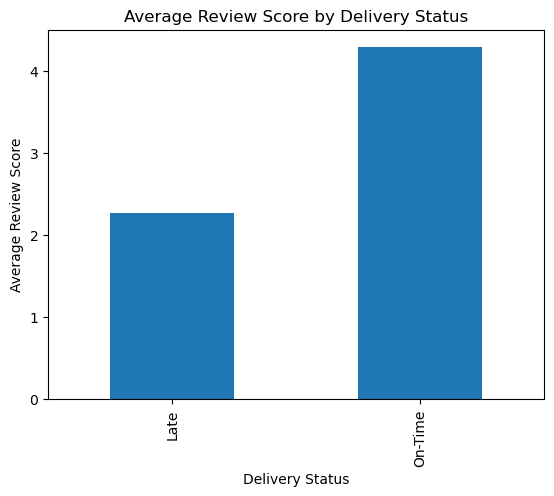

In [23]:
review_by_delivery.plot(
    kind="bar",
    title="Average Review Score by Delivery Status"
)

plt.ylabel("Average Review Score")
plt.xlabel("Delivery Status")
plt.show()

In [24]:
Q1 = late_orders["DelayDays"].quantile(0.25)
Q3 = late_orders["DelayDays"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

delay_outliers = late_orders[
    late_orders["DelayDays"] > upper_limit
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper Limit:", upper_limit)
print("Outlier Orders:", len(delay_outliers))

Q1: 3.0
Q3: 13.0
IQR: 10.0
Upper Limit: 28.0
Outlier Orders: 399
